已连接到 spacegame (Python 3.12.2)

In [ ]:
import sys
import os
project_root = '/nas1/huyulun2021/codes/spacegame-2025/psro-ppo-project'
if project_root not in sys.path:
    sys.path.insert(0, project_root)


import numpy as np
from src.utils.meta_solver import fictitious_play, maximum_entropy_nash, \
    min_support_nash, uniform_sample, naive_sp, LP_nash, \
        regularized_fictitious_play, regularized_fictitious_play_old, \
            dpp_driven_nash_, dpp_driven_nash
from src.utils.payoff_table import PayoffTable
    
import matplotlib.pyplot as plt



def calculate_exploitability(payoff_matrix, meta_strategy):
    """
    计算给定收益矩阵和元策略的Exploitability。

    参数:
    payoff_matrix (np.ndarray): n x n 的收益矩阵 U。
    meta_strategy (np.ndarray): 长度为 n 的概率分布向量 sigma。

    返回:
    float: Exploitability 的值。
    """
    # 确保输入是numpy数组
    U = np.array(payoff_matrix)
    sigma = np.array(meta_strategy)

    # 步骤2: 计算每个纯策略对抗该Meta-Strategy的期望收益
    # E_i = sum_j (U_ij * sigma_j)
    # 这等同于矩阵乘以向量
    expected_payoffs = U @ sigma
    
    # 步骤3: 找出最佳响应（Best Response）的收益
    best_response_value = np.max(expected_payoffs)
    
    # 步骤4: 在对称零和博弈中，该值即为Exploitability
    exploitability = best_response_value
    
    return exploitability


def get_submatrix(full_matrix, indices):
    """
    从完整矩阵中提取子矩阵。

    参数:
    full_matrix (np.ndarray): 完整的 n x n 矩阵。
    indices (list or np.ndarray): 要提取的行和列的索引列表。

    返回:
    np.ndarray: 提取的子矩阵。
    """
    return full_matrix[np.ix_(indices, indices)]




def get_ne_from_submatrix(payoff_matrix, meta_solver, indices):
    sub_m = get_submatrix(payoff_matrix, indices)
    r = meta_solver(PayoffTable(sub_m))

    # 兼容多种 meta_solver 返回值格式
    # LP_nash 返回 (row_strategy, col_strategy, value)
    # naive_sp/uniform_sample/fictitious_play 返回 strategy vector
    # 可能存在 (strategy, history) 这样的结构
    if isinstance(r, (tuple, list)):
        if len(r) == 3:
            row_strat = r[0]
        elif len(r) == 2 and isinstance(r[0], (np.ndarray, list)):
            row_strat = r[0]
        else:
            row_strat = np.asarray(r).ravel()
    else:
        row_strat = np.asarray(r).ravel()

    row_strat = np.asarray(row_strat, dtype=float).ravel()

    if row_strat.size != len(indices):
        raise ValueError(
            f"row_strat length {row_strat.size} != indices length {len(indices)}"
        )

    meta_full = np.zeros(payoff_matrix.shape[0], dtype=float)
    for k, idx in enumerate(indices):
        meta_full[idx] = row_strat[k]

    return meta_full, row_strat



def main(payoff_matrix, meta_solver, baseline_num=4, strat_num=50):
    results = []
    exp_raw_list = []
    for i in range(baseline_num):
        # 按照baseline分块对总的payoff做处理
        exp_list = []
        sub_m = get_submatrix(payoff_matrix, list(range(i*strat_num, (i+1)*strat_num)))
        for j in range(strat_num):
            indices = list(range(i*strat_num, i*strat_num + j + 1))
            meta_strategy, raw = get_ne_from_submatrix(payoff_matrix, meta_solver, indices)
            exp_value = calculate_exploitability(payoff_matrix, meta_strategy)

            # sub_meta = np.zeros(sub_m.shape[0])
            # sub_meta[:(raw.shape[0])] = raw
            # sub_exp_value = calculate_exploitability(sub_m, sub_meta)
            # print(f"Baseline {i}, 使用前 {j+1} 个策略的Meta-Strategy的Exploitability为: {exp_value:.4f}")

            exp_list.append(exp_value)# -sub_exp_value)
            # exp_raw_list.append(exp_value) 
        results.append(exp_list)
    return results#, exp_raw_list




In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib import rcParams

# ── IEEE Transactions style config ──────────────────────────────────────────
rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size":          9,
    "axes.labelsize":     9,
    "axes.titlesize":     9,
    "xtick.labelsize":    8,
    "ytick.labelsize":    8,
    "legend.fontsize":    8,
    "legend.framealpha":  0.9,
    "legend.edgecolor":   "0.7",
    "axes.linewidth":     0.8,
    "grid.linewidth":     0.4,
    "lines.linewidth":    1.2,
    "xtick.direction":    "in",
    "ytick.direction":    "in",
    "xtick.major.width":  0.8,
    "ytick.major.width":  0.8,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.minor.width":  0.5,
    "ytick.minor.width":  0.5,
    "pdf.fonttype":       42,   # embeds fonts for IEEE submission
    "ps.fonttype":        42,
})

# ── Color / style cycle (color-blind friendly, prints well in grayscale) ────
STYLES = [
    {"color": "#1f77b4", "linestyle": ":",  "marker": "o", "label": "NSP"},
    {"color": "#d62728", "linestyle": "--", "marker": "s", "label": "V-PSRO"},
    {"color": "#2ca02c", "linestyle": "-.", "marker": "^", "label": "U-PSRO"},
    {"color": "#ff7f0e", "linestyle": "-",  "marker": "D", "label": "SPADE-PSRO"},
]

def moving_average(x: np.ndarray, w: int = 5) -> np.ndarray:
    return np.convolve(x, np.ones(w) / w, mode="valid")

def plotting_ieee(
    data,
    labels=None,
    smooth: bool = True,
    window_size: int = 5,
    log_scale: bool = True,
    xlabel: str = "PSRO Iteration",
    ylabel: str = "Exploitability",
    title: str = None,
    save_path: str = None,
):
    """
    Plot exploitability curves in IEEE Transactions style.

    Parameters
    ----------
    data        : array-like, shape (n_algos, n_iters)
    labels      : list of str, optional — algorithm names
    smooth      : apply moving-average smoothing
    window_size : smoothing window (ignored if smooth=False)
    log_scale   : use log scale on y-axis (typical for exploitability)
    xlabel/ylabel/title : axis labels
    save_path   : if given, save figure (e.g. "fig.pdf" or "fig.png")
    """
    data = np.asarray(data, dtype=float)
    n_algos = data.shape[0]

    # Single-column IEEE width ≈ 3.5 in; double-column ≈ 7.16 in
    fig, ax = plt.subplots(figsize=(4,3))   # golden ratio ≈ 1.33

    for i in range(n_algos):
        style = STYLES[i % len(STYLES)]
        lbl   = (labels[i] if labels and i < len(labels) else style["label"])

        y = data[i]
        if smooth:
            y = moving_average(y, window_size)
        x = np.arange(len(y))

        ax.plot(
            x, y,
            color     = style["color"],
            linestyle = style["linestyle"],
            marker    = style["marker"],
            markevery = max(1, len(x) // 8),   # sparse markers → not cluttered
            markersize = 4,
            label     = lbl,
        )

    # ── Axes ─────────────────────────────────────────────────────────────────
    if log_scale:
        ax.set_yscale("log")
        ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title, pad=4)

    ax.grid(True, which="major", linestyle="--", linewidth=0.4, alpha=0.6)
    ax.grid(True, which="minor", linestyle=":",  linewidth=0.3, alpha=0.4)

    # Ticks on all four sides (IEEE style)
    ax.tick_params(which="both", top=True, right=True)

    ax.legend(loc="upper right", ncol=1, handlelength=2.0)

    fig.tight_layout(pad=0.5)

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved → {save_path}")

    plt.show()
    return fig, ax

Saved → ../tests/output/exploitability.pdf


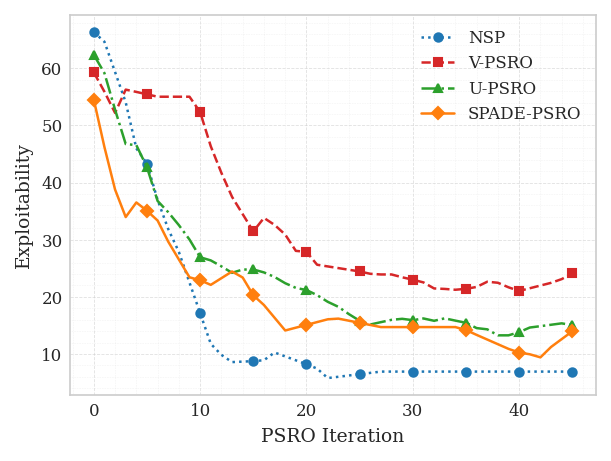

In [ ]:

payoff_ = np.load("../results/metrics/20260401_div2/payoff_final.npy")

results_  = main(payoff_,LP_nash)

fig, ax = plotting_ieee(results_, log_scale=False, save_path="../tests/output/exploitability.pdf")